# GPU Hello World

### Task 3

1. Make a NumPy matrix
2. Install, import and initialize PyCUDA
3. Make a GPU matrix
4. Copy the NumPy matrix data to the GPU
5. Write a GPU *kernel* that does some kind of computation on an input matrix
6. Copy the result back to the CPU
7. Print and plot both matrices

### Solution 3

<-- see `hello_world_pycuda_solution.ipynb`

In [1]:
# 2. Instalar y preparar PyCUDA
!pip install pycuda
import pycuda.driver as cuda
import pycuda.autoinit
from pycuda.compiler import SourceModule
import numpy as np

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 33.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 10.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 103.2/103.2 kB 13.8 MB/s eta 0:00:00
  Created wheel for pycuda: filename=pycuda-2026.1-cp312-cp312-linux_x86_64.whl size=659447 sha256=1ffcd061480c8025719566fcb87a89af14b39064f96361edcfd9931818e3def6
  Stored in directory: /root/.cache/pip/wheels/90/2a/71/75ec0cc316cc0ff494bfffa2935e02580129cb7f859a0cfd8f
Successfully built pycuda


In [3]:
# 1. Crear una matriz de NumPy (en la CPU)
a = np.random.randn(4,4).astype(np.float32)

# 3 y 4. Reservar espacio en la GPU y copiar los datos allí
a_gpu = cuda.mem_alloc(a.nbytes)
cuda.memcpy_htod(a_gpu, a) # htod = Host to Device (CPU a GPU)

In [4]:
# 5. Escribir el Kernel en C
mod = SourceModule("""
  __global__ void double_matrix(float *a)
  {
    int idx = threadIdx.x + threadIdx.y*4;
    a[idx] *= 2;
  }
  """)

# Ejecutar el kernel
func = mod.get_function("double_matrix")
func(a_gpu, block=(4,4,1))

# 6. Copiar el resultado de vuelta a la CPU
a_doubled = np.empty_like(a)
cuda.memcpy_dtoh(a_doubled, a_gpu) # dtoh = Device to Host (GPU a CPU)


In [5]:
# 7. Imprimir resultados
print("Matriz Original (CPU):")
print(a)
print("\nMatriz Procesada (GPU):")
print(a_doubled)


Matriz Original (CPU):
[[-0.414884    0.5109668   0.52624273 -0.12203064]
 [ 0.7451759   0.76215833  0.68616074  1.4024875 ]
 [ 0.2871324  -1.000186    1.2978193   0.43326572]
 [-1.6191643   0.41603902  1.0644225  -0.62112594]]

Matriz Procesada (GPU):
[[-0.829768    1.0219336   1.0524855  -0.24406128]
 [ 1.4903518   1.5243167   1.3723215   2.804975  ]
 [ 0.5742648  -2.000372    2.5956385   0.86653143]
 [-3.2383287   0.83207804  2.128845   -1.2422519 ]]


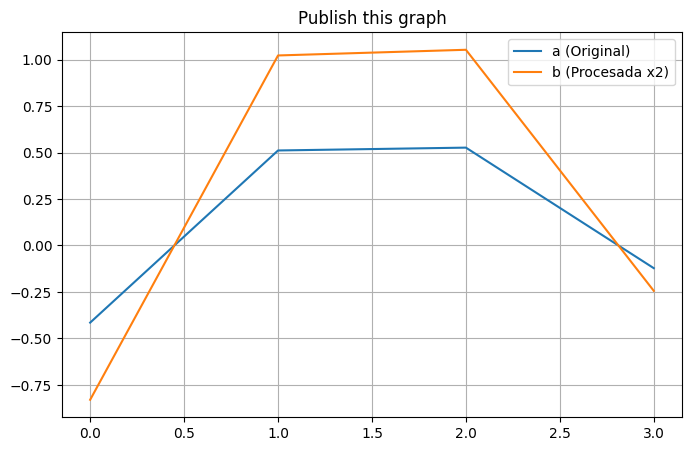

In [7]:
import matplotlib.pyplot as plt

# Usamos la primera fila de cada matriz para la comparativa
fila_original = a[0,:]
fila_procesada = a_doubled[0,:]

plt.figure(figsize=(8, 5))
plt.plot(fila_original, label='a (Original)')
plt.plot(fila_procesada, label='b (Procesada x2)')

plt.title('Publish this graph')
plt.legend()
plt.grid(True)
plt.show()
